In [4]:
# import libraries for data manipulation, numerical computation, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# load call center dataset into a DataFrame
df = pd.read_csv("ConnectTel_Kenya_Call_Center_50k.csv")

In [6]:
# check number of rows and columns in the dataset
df.shape

(50000, 22)

In [7]:
# display all columns when viewing the DataFrame (no truncation)
pd.set_option('display.max_columns', None)

In [8]:
# preview first 5 rows of the dataset
df.head()

,call_id,timestamp,day,hour,call_center,agent_id,agent_team,agent_experience_years,issue_type,customer_segment,subscription_type,tenure_months,previous_calls_30d,region,language,chatbot_transfer,queue_length,holiday,mpesa_outage,rainfall_mm,network_incident,call_duration_min
0,CT000001,2025-08-24 19:23,Sunday,19,Eldoret,AG031,A,5.6,Network,Personal,Postpaid,162,0,Nairobi,Kiswahili,Yes,37,0,0,6.8,0,14.1
1,CT000002,2025-02-06 02:38,Thursday,2,Kisumu,AG050,A,8.2,M-PESA,Personal,Prepaid,159,1,Kisumu,Kiswahili,No,40,0,0,3.1,0,8.9
2,CT000003,2025-11-08 08:43,Saturday,8,Eldoret,AG148,A,12.0,SIM Swap,Personal,Prepaid,108,2,Mombasa,Kiswahili,Yes,20,0,0,6.5,0,8.4
3,CT000004,2025-04-21 16:07,Monday,16,Kisumu,AG243,A,5.2,Data Bundle,Personal,Prepaid,180,0,Nakuru,Kiswahili,No,36,0,0,5.2,0,3.3
4,CT000005,2025-07-27 05:40,Sunday,5,Eldoret,AG042,B,2.7,Data Bundle,Personal,Prepaid,141,0,Nakuru,English,No,8,0,0,0.0,0,7.4


In [9]:
# check column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   call_id                 50000 non-null  object 
 1   timestamp               50000 non-null  object 
 2   day                     50000 non-null  object 
 3   hour                    50000 non-null  int64  
 4   call_center             50000 non-null  object 
 5   agent_id                50000 non-null  object 
 6   agent_team              50000 non-null  object 
 7   agent_experience_years  50000 non-null  float64
 8   issue_type              50000 non-null  object 
 9   customer_segment        50000 non-null  object 
 10  subscription_type       50000 non-null  object 
 11  tenure_months           50000 non-null  int64  
 12  previous_calls_30d      50000 non-null  int64  
 13  region                  50000 non-null  object 
 14  language                50000 non-null

In [10]:
# count duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [11]:
# convert timestamp column to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

Text(0.5, 1.0, 'Call Duration Distribution')

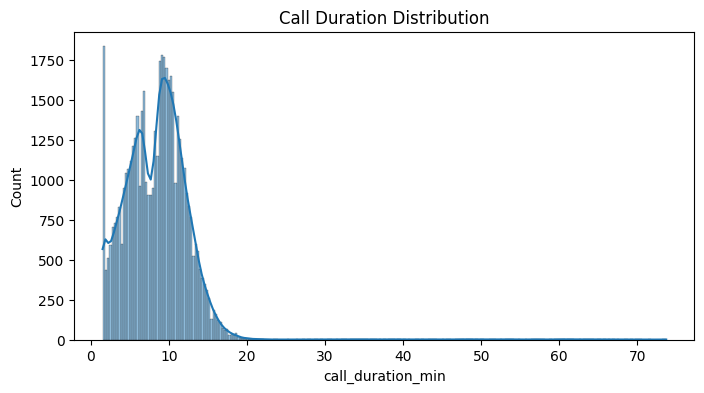

In [13]:
# plot distribution of call duration with histogram and KDE overlay
plt.figure(figsize=(8,4))
sns.histplot(df['call_duration_min'], kde=True)
plt.title("Call Duration Distribution")

Text(0.5, 1.0, 'Log(Call Duration) Distribution')

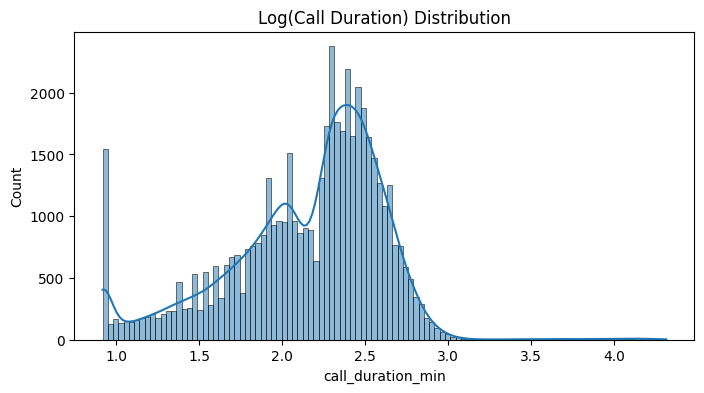

In [14]:
# plot log-transformed call duration distribution to reduce skewness
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df['call_duration_min']), kde=True)
plt.title("Log(Call Duration) Distribution")

In [15]:
# get list of numeric columns, excluding call_duration_min (target variable)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove("call_duration_min")

In [16]:
# check correlation of numeric features with call_duration_min
corr = df[num_cols + ['call_duration_min']].corr()['call_duration_min'].sort_values(ascending=False)
print(corr)

call_duration_min         1.000000
previous_calls_30d        0.349054
queue_length              0.118761
network_incident          0.014728
mpesa_outage              0.009359
holiday                   0.009004
hour                      0.007669
tenure_months             0.001027
rainfall_mm              -0.003285
agent_experience_years   -0.231870
Name: call_duration_min, dtype: float64


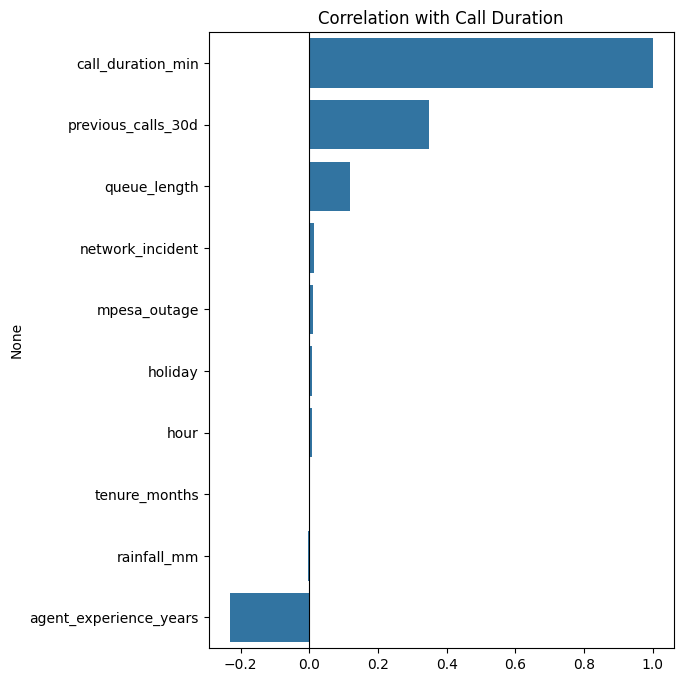

In [17]:
# visualize correlation values as a horizontal bar plot
plt.figure(figsize=(6, 8))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Correlation with Call Duration")
plt.axvline(0, color="black", linewidth=0.8)

Text(0.5, 1.0, 'Correlation Heatmap')

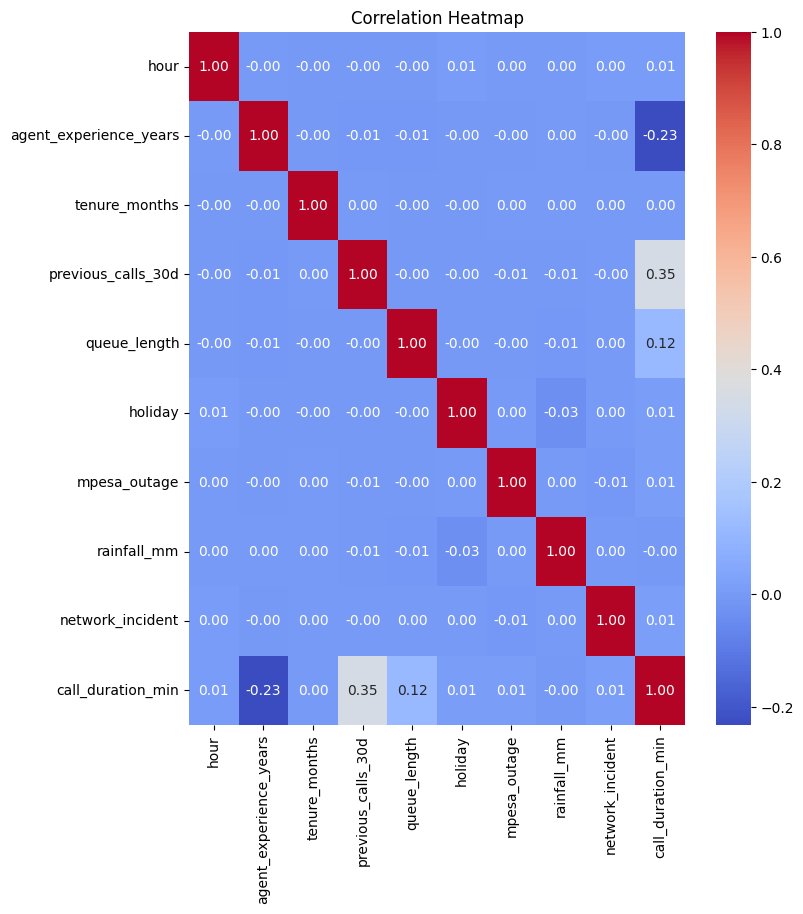

In [18]:
# visualize correlation matrix of numeric features as a heatmap
plt.figure(figsize=(8, 9))
sns.heatmap(df[num_cols + ["call_duration_min"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")

In [20]:
# check number of unique values in each categorical column
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols]
for col in cat_cols:
  print(col, df[col].nunique())

call_id 50000
day 7
call_center 4
agent_id 450
agent_team 4
issue_type 8
customer_segment 3
subscription_type 2
region 8
language 2
chatbot_transfer 2


In [21]:
# drop identifier columns and one-hot encode low-cardinality categorical features
df = df.drop(columns=["agent_id", "call_id"])
low_card_cols = ["issue_type", "customer_segment", "subscription_type",
                  "region", "language", "chatbot_transfer", "call_center", "agent_team", "day"]
df_encoded = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

In [22]:
# check shape and column names after encoding
print(df_encoded.shape)
print(df_encoded.columns.tolist())

(50000, 42)
['timestamp', 'hour', 'agent_experience_years', 'tenure_months', 'previous_calls_30d', 'queue_length', 'holiday', 'mpesa_outage', 'rainfall_mm', 'network_incident', 'call_duration_min', 'issue_type_Billing', 'issue_type_Data Bundle', 'issue_type_Device', 'issue_type_M-PESA', 'issue_type_Network', 'issue_type_Roaming', 'issue_type_SIM Swap', 'customer_segment_Personal', 'customer_segment_SME', 'subscription_type_Prepaid', 'region_Kisumu', 'region_Machakos', 'region_Mombasa', 'region_Nairobi', 'region_Nakuru', 'region_Nyeri', 'region_Uasin Gishu', 'language_Kiswahili', 'chatbot_transfer_Yes', 'call_center_Kisumu', 'call_center_Mombasa', 'call_center_Nairobi', 'agent_team_B', 'agent_team_C', 'agent_team_D', 'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']


In [23]:
# drop timestamp column since it's not usable directly for modeling
drop_cols = ['timestamp']
df_model = df_encoded.drop(columns=[c for c in drop_cols if c in df_encoded.columns])

In [24]:
# check shape and columns of final modeling dataset
print(df_model.shape)
print(df_model.columns)

(50000, 41)
Index(['hour', 'agent_experience_years', 'tenure_months', 'previous_calls_30d',
       'queue_length', 'holiday', 'mpesa_outage', 'rainfall_mm',
       'network_incident', 'call_duration_min', 'issue_type_Billing',
       'issue_type_Data Bundle', 'issue_type_Device', 'issue_type_M-PESA',
       'issue_type_Network', 'issue_type_Roaming', 'issue_type_SIM Swap',
       'customer_segment_Personal', 'customer_segment_SME',
       'subscription_type_Prepaid', 'region_Kisumu', 'region_Machakos',
       'region_Mombasa', 'region_Nairobi', 'region_Nakuru', 'region_Nyeri',
       'region_Uasin Gishu', 'language_Kiswahili', 'chatbot_transfer_Yes',
       'call_center_Kisumu', 'call_center_Mombasa', 'call_center_Nairobi',
       'agent_team_B', 'agent_team_C', 'agent_team_D', 'day_Monday',
       'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday',
       'day_Wednesday'],
      dtype='object')


In [25]:
# split dataset into features (X) and target variable (y)
X = df_model.drop(columns=['call_duration_min'])
y = df_model['call_duration_min']

In [26]:
# split data into training and testing sets (80/20 split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# train a linear regression model on the training data
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [28]:
# generate predictions on the test set
y_pred = lr.predict(X_test)

In [29]:
# compute MAE, RMSE, and R2 to evaluate model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [30]:
# print evaluation metrics
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")


MAE:  1.305
RMSE: 2.662
R²:   0.603


In [31]:
# check mean call duration for context on error magnitude
df['call_duration_min'].mean()

np.float64(8.410634)

In [88]:
# compare model performance against a naive baseline (predicting the mean)
naive_pred = np.full_like(y_test, y_train.mean(), dtype=float)

print("Naive MAE: ", mean_absolute_error(y_test, naive_pred))
print("Naive RMSE: ", np.sqrt(mean_squared_error(y_test, naive_pred)))
print("R2 Score: ", r2_score(y_test, naive_pred))

Naive MAE:  3.0659349330000003
Naive RMSE:  4.221910456905143
R2 Score:  -7.4131559182344375e-06


In [33]:
# view feature coefficients to see their impact on predicted call duration
coef_df = pd.DataFrame({
    "Feature":X.columns,
    "coefficient":lr.coef_
}).sort_values("coefficient", ascending=False)
print(coef_df)

                      Feature  coefficient
13         issue_type_Network     7.128098
14         issue_type_Roaming     5.392311
9          issue_type_Billing     4.787527
12          issue_type_M-PESA     4.465574
11          issue_type_Device     3.733890
15        issue_type_SIM Swap     3.134129
27       chatbot_transfer_Yes     2.027645
17       customer_segment_SME     0.969968
16  customer_segment_Personal     0.936558
3          previous_calls_30d     0.766547
10     issue_type_Data Bundle     0.489073
5                     holiday     0.424012
6                mpesa_outage     0.284469
8            network_incident     0.210338
37               day_Thursday     0.127969
32               agent_team_C     0.096379
34                 day_Monday     0.093234
36                 day_Sunday     0.047056
28         call_center_Kisumu     0.042468
22             region_Nairobi     0.038634
38                day_Tuesday     0.037654
4                queue_length     0.027831
25         

Text(0.5, 1.0, 'Residual Plot')

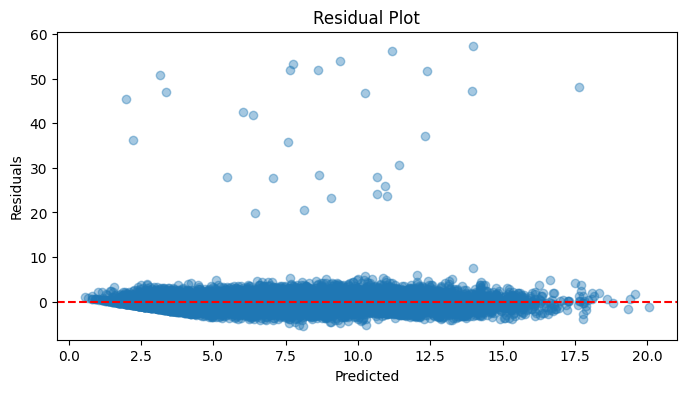

In [34]:
# plot residuals vs predicted values to check for patterns or heteroscedasticity
residuals = y_test-y_pred
plt.figure(figsize=(8,4))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")


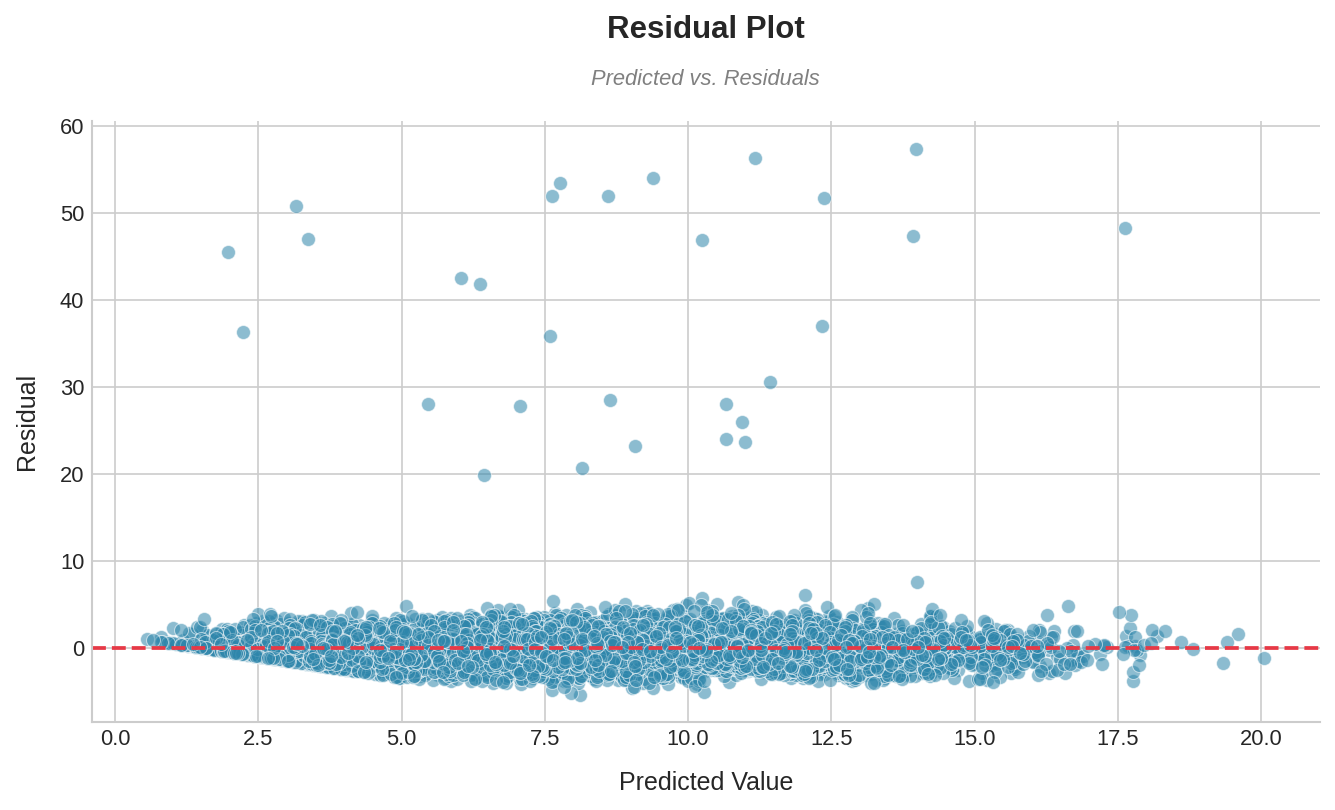

In [99]:
# refined residual plot with cleaner styling and saved as high-res image
import matplotlib.ticker as ticker

residuals = y_test - y_pred

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

ax.scatter(y_pred, residuals, alpha=0.55, s=45,
           color="#2E86AB", edgecolor="white", linewidth=0.5)

ax.axhline(0, color="#E63946", linestyle="--", linewidth=1.8, zorder=1)

ax.set_xlabel("Predicted Value", fontsize=12, fontweight="medium", labelpad=10)
ax.set_ylabel("Residual", fontsize=12, fontweight="medium", labelpad=10)
ax.set_title("Residual Plot", fontsize=15, fontweight="bold", pad=40)

# subtitle-style annotation for context
ax.text(0.5, 1.06, "Predicted vs. Residuals",
        transform=ax.transAxes, ha="center", fontsize=10.5,
        color="gray", style="italic")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=10.5)

plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Text(0.5, 1.0, 'Actual vs Predicted')

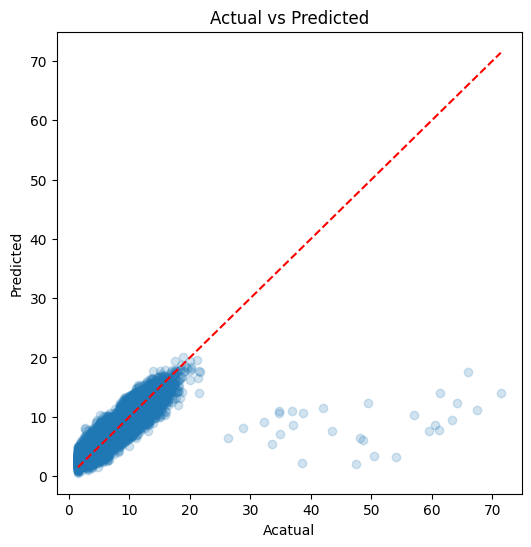

In [51]:
# plot actual vs predicted values to visually assess model fit
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")


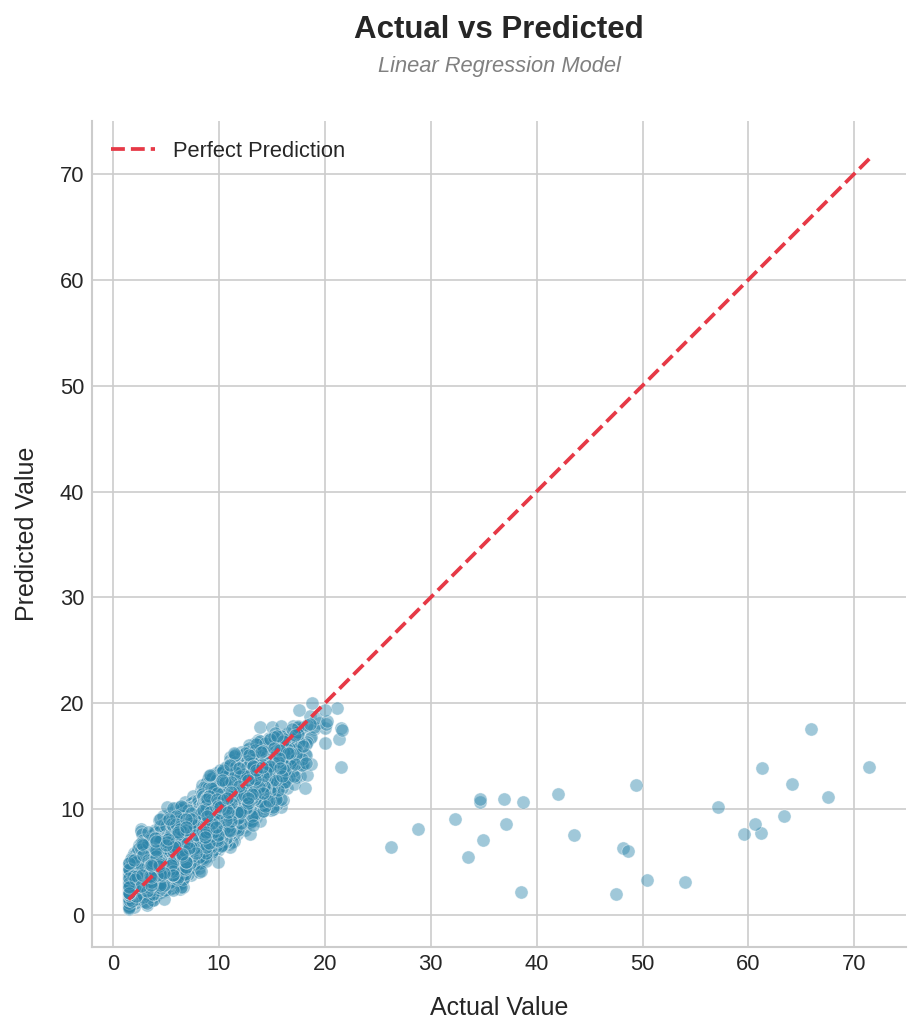

In [101]:
# refined actual vs predicted plot with cleaner styling and saved as high-res image
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(7, 7), dpi=150)

ax.scatter(y_test, y_pred, alpha=0.45, s=40,
           color="#2E86AB", edgecolor="white", linewidth=0.4)

lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "--", color="#E63946", linewidth=1.8, label="Perfect Prediction")

ax.set_xlabel("Actual Value", fontsize=12, fontweight="medium", labelpad=10)
ax.set_ylabel("Predicted Value", fontsize=12, fontweight="medium", labelpad=10)
ax.set_title("Actual vs Predicted", fontsize=15, fontweight="bold", pad=40)

ax.text(0.5, 1.06, "Linear Regression Model",
        transform=ax.transAxes, ha="center", fontsize=10.5,
        color="gray", style="italic")

ax.set_aspect("equal", adjustable="box")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=10.5)
ax.legend(frameon=False, fontsize=10.5, loc="upper left")

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [60]:
# check multicollinearity among features using Variance Inflation Factor (VIF)
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = X_train.copy()
X_vif = X_vif.astype(float)
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data["Feature"] != "const"].sort_values("VIF", ascending=False)
print(vif_data)

                      Feature       VIF
17  customer_segment_Personal  3.126539
18       customer_segment_SME  3.126386
14         issue_type_Network  1.858578
15         issue_type_Roaming  1.855362
10         issue_type_Billing  1.845374
13          issue_type_M-PESA  1.824034
12          issue_type_Device  1.797972
16        issue_type_SIM Swap  1.782800
24              region_Nakuru  1.773669
26         region_Uasin Gishu  1.761854
23             region_Nairobi  1.754652
20              region_Kisumu  1.752118
25               region_Nyeri  1.751232
22             region_Mombasa  1.747105
21            region_Machakos  1.744904
11     issue_type_Data Bundle  1.743795
36               day_Saturday  1.726978
39                day_Tuesday  1.721944
37                 day_Sunday  1.721573
40              day_Wednesday  1.720606
38               day_Thursday  1.716820
35                 day_Monday  1.714568
34               agent_team_D  1.512612
32               agent_team_B  1.511144


In [91]:
# train a Random Forest model and evaluate its performance for comparison
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RF MAE: ", mean_absolute_error(y_test, rf_pred))
print("RF RMSE: ", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("RF R2: ", r2_score(y_test, rf_pred))

RF MAE:  1.42735995
RF RMSE:  2.847973623240742
RF R2:  0.5449521059319226
